# Project: Global Fitness Search Trends: Market Analysis

**Objective:** Analyze international Google Trends data related to fitness and workout keywords to identify changes in consumer interest, understand the impact of the COVID-19 pandemic, and determine which markets and fitness segments show the strongest demand.

**Business Questions:**

* In which year did global interest in the search term **“workout”** reach its highest point?
* Which keyword was the most popular during the COVID-19 pandemic, and which is currently the most popular?
* Which of **Japan, the United States, and Australia** had the highest overall interest in workouts?
* Which of **the Philippines and Malaysia** had the highest interest in home workouts?

**Data Used:**

* `workout.csv`
* `three_keywords.csv`
* `workout_geo.csv`
* `three_keywords_geo.csv`

The datasets contain:

* `month` : Month when the data was measured.
* `workout_worldwide` : Popularity index for the keyword **“workout”** worldwide.
* `home_workout_worldwide` : Popularity index for **“home workout”** worldwide.
* `gym_workout_worldwide` : Popularity index for **“gym workout”** worldwide.
* `home_gym_worldwide` : Popularity index for **“home gym”** worldwide.
* `country` : Country where the data was measured.
* `workout_2018_2023` : Popularity index for **“workout”** over the 2018–2023 period.
* `home_workout_2018_2023` : Popularity index for **“home workout”** over the 2018–2023 period.
* `gym_workout_2018_2023` : Popularity index for **“gym workout”** over the 2018–2023 period.
* `home_gym_2018_2023` : Popularity index for **“home gym”** over the 2018–2023 period.

**Methodology:**

1. Import the required Python libraries and load the four Google Trends datasets.
2. Sort the worldwide workout data by popularity to identify the year with the highest global interest in **“workout.”**
3. Convert the relevant date columns to datetime format and visualize worldwide workout interest over time using a line plot.
4. Reshape the three-keyword worldwide dataset from wide to long format and rename the keyword categories for clearer analysis and visualization.
5. Compare the popularity of **Home Workout, Gym Workout, and Home Gym** over time to identify the most popular keyword during COVID-19 and the current period.
6. Filter the geographic workout data to **Japan, the United States, and Australia**, then compare their overall workout interest using a bar plot.
7. Filter the geographic keyword data to **the Philippines and Malaysia**, reshape it into long format, and compare the popularity of the different workout segments.
8. Store the final answers to the business questions in the corresponding Python variables.

**Output Objects:**

* `year_str` : Year in which worldwide interest in **“workout”** was highest.
* `peak_covid` : Most popular workout-related keyword during the COVID-19 pandemic.
* `current` : Currently most popular workout-related keyword.
* `top_country` : Country with the highest overall workout interest among Japan, the United States, and Australia.
* `home_workout_geo` : Country with the highest interest in **“home workout”** between the Philippines and Malaysia.

One small correction to your code: in question 4, your dataset description uses **`country`** in lowercase, but your code uses **`Country`**. Make sure you use whichever capitalization actually exists in the DataFrame.


In [1]:
# Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import all four CSV files
workout = pd.read_csv('data/workout.csv')
workout_geo = pd.read_csv('data/workout_geo.csv')
three_key = pd.read_csv('data/three_keywords.csv')
three_key_geo = pd.read_csv('data/three_keywords_geo.csv')

In [3]:
# 1. In which year did global interest in the search term “workout” reach its highest point?

# Sort the workout dataframe by workout_worldwide and assign to a new df: global_search
global_search = workout.sort_values(
    by='workout_worldwide', 
    ascending=False)

# Take the first four characters of the first value in the month column. These four characters represent the year. Assign to year_str
year_str = global_search['month'].iloc[0][:4]
year_str

'2020'

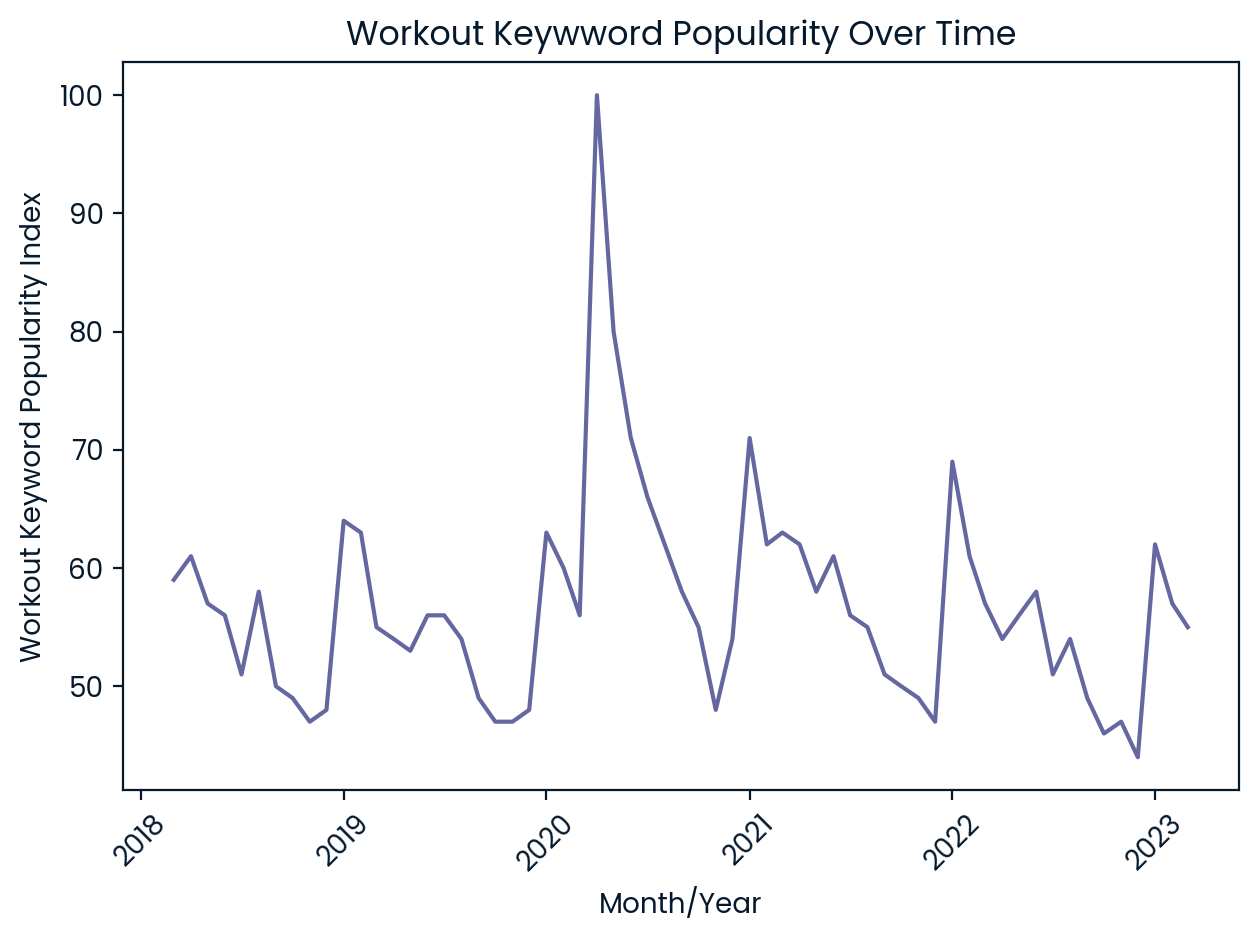

In [4]:
# Visualize it: Convert the month column of the global_search dataframe to a date format, and create a lineplot
global_search['month'] = pd.to_datetime(global_search['month'])
sns.lineplot(global_search, 
             x='month', 
             y='workout_worldwide')

plt.xticks(rotation = 45)
plt.xlabel('Month/Year')
plt.ylabel('Workout Keyword Popularity Index')
plt.title('Workout Keywword Popularity Over Time')
plt.tight_layout()
plt.show()

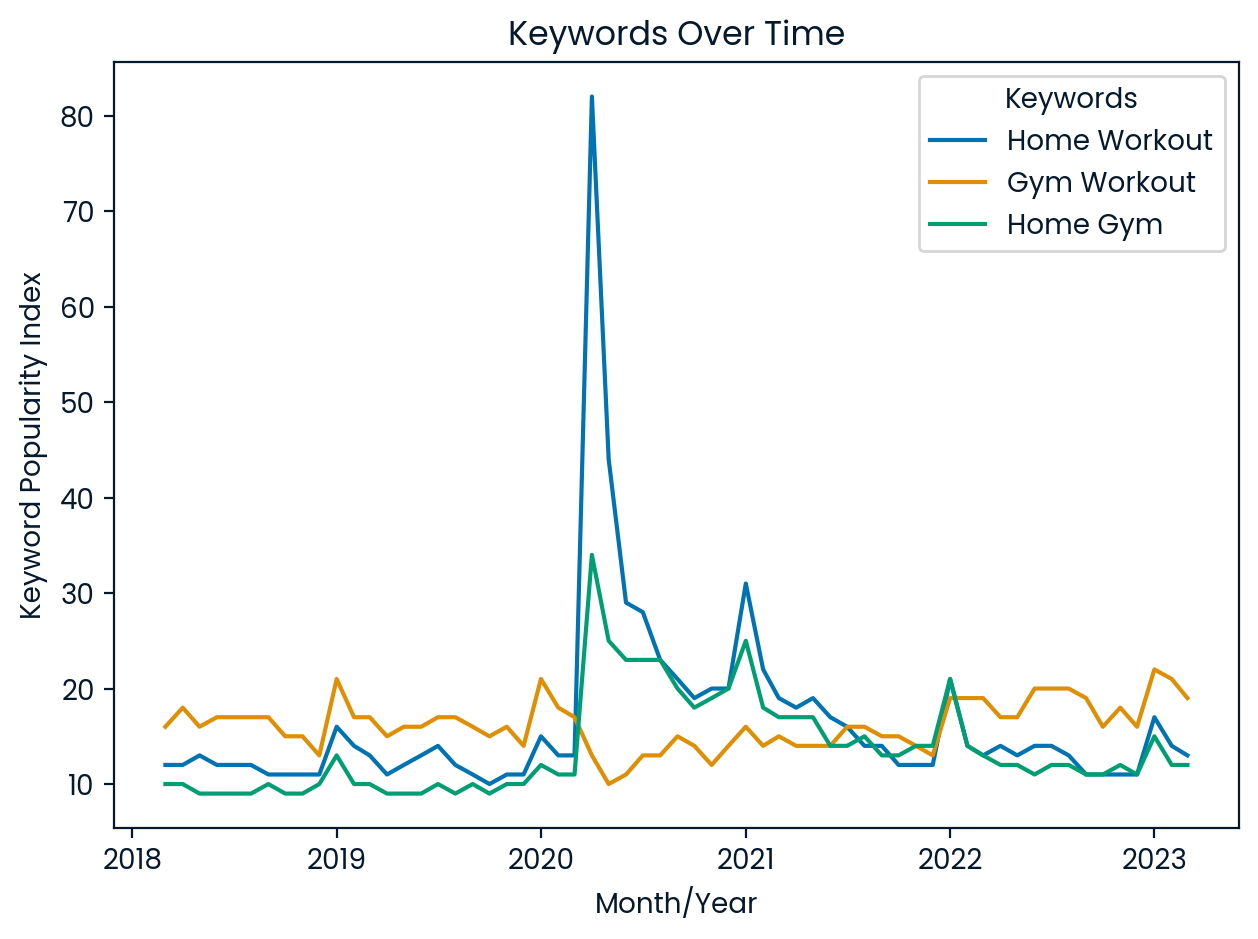

In [5]:
# 2. Which of the available keywords was the most popular during the COVID pandemic, and which is currently the most popular?

# Convert the month column of the three_key dataframe to a date format
three_key['month'] = pd.to_datetime(three_key['month'])

# Convert the three_key dataframe from wide to long format: three_key_pop, using month as the ID variable
three_key_pop = three_key.melt(
    id_vars = 'month',
    var_name = 'category',
    value_name = 'pop_index'
)

# Rename the category variables to more readable names
three_key_pop['category'] = (three_key_pop['category']
                             .replace(
                                 {'home_workout_worldwide':'Home Workout', 
                                  'gym_workout_worldwide':'Gym Workout', 
                                  'home_gym_worldwide':'Home Gym'}))

# Define the desired order of the category variables for the visualization
order = ['Home Workout', 'Gym Workout', 'Home Gym']

# Create a lineplot and use the specified order for categories
sns.lineplot(three_key_pop, 
             x='month', 
             y='pop_index', 
             hue='category', 
             hue_order = order,
             palette = 'colorblind')

plt.legend(title = 'Keywords')
plt.ylabel('Keyword Popularity Index')
plt.xlabel('Month/Year')
plt.title('Keywords Over Time')
plt.tight_layout()
plt.show()

In [6]:
# Assign the most popular keywords during COVID and currently to the respective variables
peak_covid = 'Home Workout'
current = 'Gym Workout'

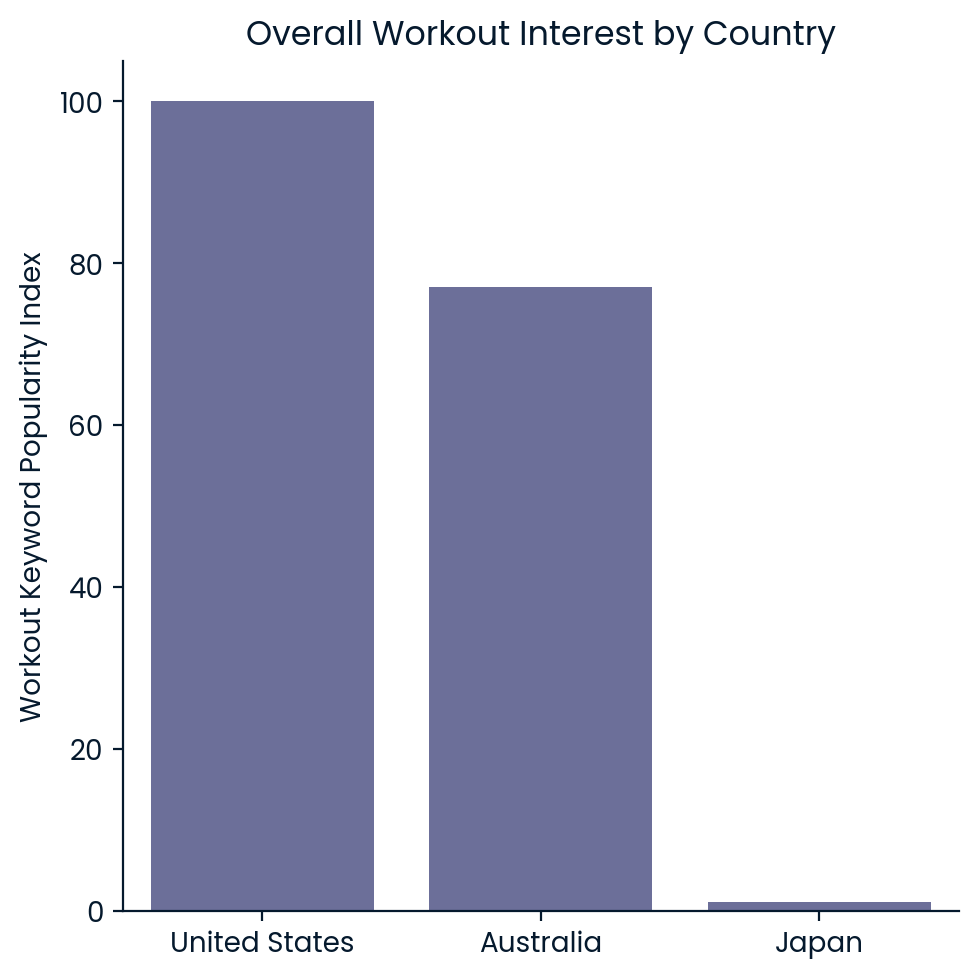

In [7]:
# 3. Which of these three countries(Japan, the United States, and Australia) had the highest interest in workouts?

# Filter the workout_geo df to include only the U.S, Japan, and Australia
geo_countries = (workout_geo[workout_geo['country']
                 .isin(
                     ['United States',
                      'Japan',
                      'Australia'])])

# Create a barplot to find the country with the highest interest
sns.catplot(geo_countries, 
            x='country', 
            y= 'workout_2018_2023', 
            kind='bar')

plt.ylabel('Workout Keyword Popularity Index')
plt.xlabel(None)
plt.title('Overall Workout Interest by Country')
plt.tight_layout()
plt.show()

In [8]:
# Assign the country to top_country
top_country = 'United States'

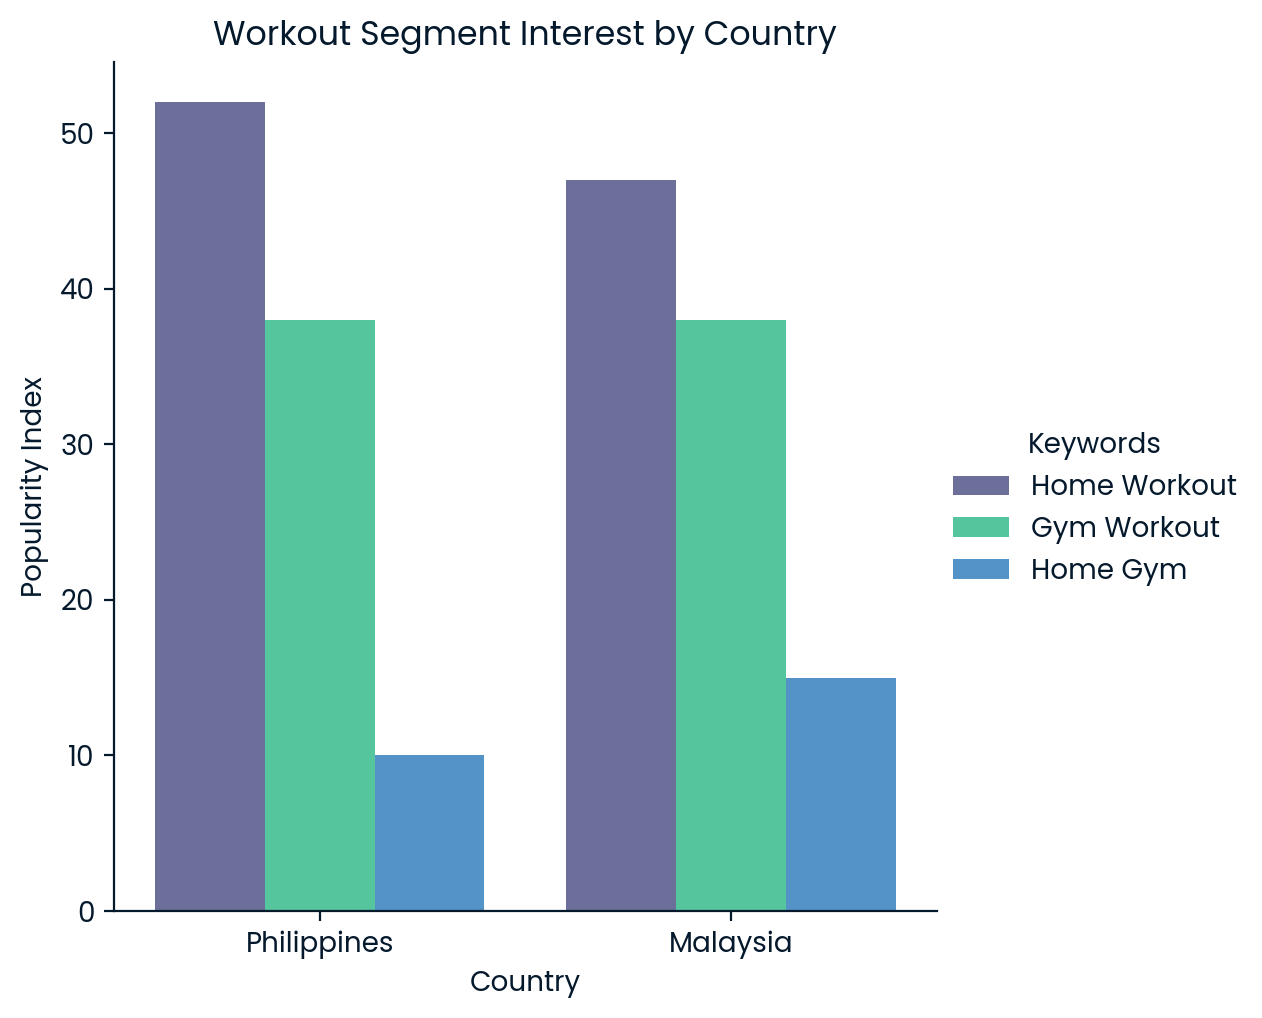

In [9]:
# 4. Which of the two countries, the Philippines or Malaysia, has the highest interest in home workouts?

# Filter the three_key_geo df to include only the Philippines and Malaysia
mal_philip_key = (three_key_geo[three_key_geo['Country']
                  .isin(
                      ['Philippines', 
                       'Malaysia'])])

# Convert the dataframe from wide to long format, using 'Country' as the ID variable
mal_philip_melt = mal_philip_key.melt(
    id_vars = 'Country',
    var_name = 'Keywords',
    value_name = 'Popularity Index'
)

# Rename the Keywords variables to more readable names
mal_philip_melt['Keywords'] = (mal_philip_melt['Keywords']
                               .replace({
                                   'home_workout_2018_2023': 'Home Workout',
                                   'gym_workout_2018_2023': 'Gym Workout',
                                   'home_gym_2018_2023': 'Home Gym'}))

# Create a barplot
sns.catplot(
    mal_philip_melt,
    x = 'Country',
    y = 'Popularity Index',
    hue = 'Keywords',
    kind = 'bar'
)

plt.title('Workout Segment Interest by Country')
plt.show()

In [10]:
# Assign the country with the highest interest in home workouts to home_workout_geo.
home_workout_geo = 'Philippines'